# Tokenisation from scratch — l'unité de compte de tout le dépôt

Une phrase est une suite de **mots** ; un modèle la voit comme une suite de **tokens**. Ce notebook construit une tokenisation **Byte-Pair Encoding (BPE)** à la main, en la comparant aux deux extrêmes naïfs (mots, caractères), puis au **tokenizer réel** de la stack (un Qwen auto-hébergé). L'objectif n'est pas la mécanique seule : il montre **le coût d'un choix de tokenizer** sur le chunking RAG et le budget de contexte.

C'est le quatrième notebook de la série RAG. Le [03-Embeddings](03-Embeddings-From-Scratch.ipynb) expliquait ce qu'est un *embedding* ; celui-ci explique l'**unité de compte** — le token — que toute la série consomme sans jamais le construire.

## 1. Objectif — le token est partout, et jamais construit

Un grep sur tout `GenAI/` et `ML/` ne trouve **aucun** notebook qui enseigne la tokenisation texte — les seuls « tokenizers » du dépôt sont audio (TTS/STT). Or le token est le premier étage de tout ce que le dépôt manipule :

- les **counts** des notebooks RAG (chunks → tokens) ;
- les **budgets de contexte** des notebooks agents ;
- le **pricing** des API (facturé au token) ;
- la **longueur max d'entraînement** en FineTuning / PostTraining (`max_length`) ;
- jusqu'au **QLoRA** (séquences tronquées à `max_length`).

On consomme des tokens partout sans jamais en construire un. Ce notebook construit le plus simple d'entre eux — un **BPE** — et le confronte à un vrai tokenizer de modèle.

## 2. Un corpus français borné

Le corpus est **défini dans ce notebook** : quelques fables de La Fontaine (domaine public), minuscules, découpées en mots. Il est volontairement borné — c'est un corpus *pédagogique*, pas un benchmark. Sa taille est fixée pour que la fréquence des paires soit lisible.

In [1]:
# Corpus français borné et reproductible : fables de La Fontaine (domaine public).
FABLES_TEXT = """
Maître Corbeau, sur un arbre perché, tenait en son bec un fromage.
Maître Renard, par l'odeur alléché, lui tint à peu près ce langage.
Hé bonjour, Monsieur du Corbeau. Que vous êtes joli, que vous me semblez beau.
Sans mentir, si votre ramage se rapporte à votre plumage, vous êtes le Phénix des hôtes de ces bois.
Le corbeau, honteux et confus, jura, mais un peu tard, qu'on ne l'y prendrait plus.
La cigale ayant chanté tout l'été, se trouva fort dépourvue quand la bise fut venue.
Pas un seul petit morceau de mouche ou de vermisseau, elle alla crier famine chez la fourmi sa voisine.
Je vous paierai, lui dit-elle, avant l'août, foi d'animal, intérêt et principal.
La fourmi n'est pas prêteuse, c'est là son moindre défaut.
Que faisiez-vous au temps chaud, dit-elle à cette emprunteuse.
Nuit et jour à tout venant je chantais, ne vous déplaise.
Vous chantiez, j'en suis fort aise, eh bien dansez maintenant.
Le lièvre et la tortue firent une course, et la tortue, lente mais obstinée,
gagna contre le lièvre trop confiant.
Rien ne sert de courir, il faut partir à point, la patience vaut mieux que la force.
Le lion, roi des animaux, apprit un jour que les bêtes de son royaume le craignaient.
Le rat des villes et le rat des champs se rencontrèrent et partagèrent leur repas.
Le loup et l'agneau se désaltéraient au même ruisseau, le loup chercha une querelle à l'agneau.
Le corbeau et le renard se parlèrent longtemps, le renard eut le fromage.
Le chêne et le roseau se disputaient la force, le vent les départagea.
Perrette et le pot au lait, la poule aux œufs d'or, le coq et le renard.
Le savetier et le financier, le sage et le fou, le laboureur et ses enfants.
""".strip()

import re, collections
# Découpage en mots : lettres accentuées, apostrophe, chiffres, tiret.
WORDS = re.findall(r"[a-zà-ÿ'éèêëïôöûüç0-9-]+", FABLES_TEXT.lower())

print(f"Le corpus fait {len(WORDS)} mots, {len(set(WORDS))} mots distincts.")
print("Aperçu :", WORDS[:12])

Le corpus fait 299 mots, 188 mots distincts.
Aperçu : ['maître', 'corbeau', 'sur', 'un', 'arbre', 'perché', 'tenait', 'en', 'son', 'bec', 'un', 'fromage']


### Lecture du résultat

Le corpus est **borné** (quelques centaines de mots) et **reproductible** (chaîne littérale dans la cellule). C'est la condition pour comparer des tokenizers *sur la même base* et pour que les comptes soient vérifiables.

## 3. Les deux extrêmes — tokenizer « mots » et tokenizer « caractères »

Avant BPE, deux choix naïfs bornent l'espace :

- **par mots** : chaque mot = un token. Vocabulaire **énorme** (un token par mot possible), les mots rares sont toujours hors-vocabulaire.
- **par caractères** : chaque caractère = un token. Vocabulaire minuscule, mais chaque mot est découpé en beaucoup de tokens (séquences longues).

On mesure les deux sur le corpus.

In [2]:
# Les deux extrêmes : vocabulaire et longueur de séquence.
def vocab_tokenize(words):
    return {w for w in words}   # un token par mot distinct

def char_tokenize(words):
    return {c for w in words for c in w}   # un token par caractère

vocab_mots = vocab_tokenize(WORDS)
vocab_chars = char_tokenize(WORDS)
tokens_par_mot_caracteres = sum(len(w) for w in WORDS) / len(WORDS)

print(f"Tokenizer MOTS       : vocabulaire = {len(vocab_mots):>3}  | tokens/texte ~ {len(WORDS):>3}  (1 token par mot, trivialement)")
print(f"Tokenizer CARACTERES : vocabulaire = {len(vocab_chars):>3}  | tokens/texte ~ {sum(len(w) for w in WORDS):>3}  | en moyenne {tokens_par_mot_caracteres:.2f} token/mot")
print()
print("Vocabulaire caractères :", sorted(vocab_chars))

Tokenizer MOTS       : vocabulaire = 188  | tokens/texte ~ 299  (1 token par mot, trivialement)
Tokenizer CARACTERES : vocabulaire =  33  | tokens/texte ~ 1313  | en moyenne 4.39 token/mot

Vocabulaire caractères : ["'", '-', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', 'à', 'è', 'é', 'ê', 'î', 'ô', 'û']


### Lecture du résultat

Les deux extrêmes sont deux façons de perdre :

- **mots** : vocabulaire *ouvert* (il grandit à chaque mot nouveau), risque de hors-vocabulaire constant, compression faible.
- **caractères** : vocabulaire fermé mais **séquences longues** (~`tokens_par_mot_caracteres` tokens par mot) — le modèle travaille sur des suites inutilement longues.

BPE est le compromis : un vocabulaire **fermé** dont les unités sont des **fragments de mots** appris par fréquence.

## 4. Byte-Pair Encoding — fusionner les paires les plus fréquentes

Le principe : répéter **« compte les paires adjacentes, fusionne la plus fréquente »** jusqu'à la taille de vocabulaire voulue.

1. On découpe chaque mot en caractères, avec un marqueur de fin de mot `</w>`.
2. Sur tout le corpus, on compte les paires de symboles adjacents.
3. On fusionne la paire la plus fréquente **partout où elle apparaît** → elle devient un nouveau symbole.
4. On recommence : chaque fusion ajoute un symbole au vocabulaire et raccourcit les séquences.

L'**ordre des fusions** est le résultat à observer : les premières fusionnent les suites les plus courantes du corpus.

In [3]:
# Entraînement BPE : on répète « compter les paires, fusionner la plus fréquente ».
def train_bpe(words, n_merges):
    # Chaque mot devient une liste de symboles ; </w> marque la fin du mot.
    word_symbols = [list(w) + ['</w>'] for w in words]
    merges = []   # ordre d'apprentissage : la liste des paires fusionnées
    for _ in range(n_merges):
        # (1) compter les paires adjacentes sur tout le corpus
        pair_counts = collections.Counter()
        for syms in word_symbols:
            for i in range(len(syms) - 1):
                pair_counts[(syms[i], syms[i + 1])] += 1
        if not pair_counts:
            break
        # (2) la paire la plus fréquente (ex æquo => ordre lexical, pour être déterministe)
        best = max(pair_counts, key=lambda p: (pair_counts[p], p))
        if pair_counts[best] < 2:
            break
        merges.append(best)
        # (3) fusionner cette paire partout
        new_symbols = []
        for syms in word_symbols:
            out, i = [], 0
            while i < len(syms):
                if i < len(syms) - 1 and (syms[i], syms[i + 1]) == best:
                    out.append(syms[i] + syms[i + 1]); i += 2
                else:
                    out.append(syms[i]); i += 1
            new_symbols.append(out)
        word_symbols = new_symbols
    return merges

MERGES = train_bpe(WORDS, 60)
print(f"{len(MERGES)} fusions apprises.")
print()
print("Ordre des 18 premières fusions (la morphologie du corpus émerge) :")
for i, (a, b) in enumerate(MERGES[:18], 1):
    print(f"  {i:>2}. {a!r} + {b!r} -> {a+b!r}")
print()
print("Dernières fusions :")
for i, (a, b) in enumerate(MERGES[-4:], len(MERGES) - 3):
    print(f"  {i:>2}. {a!r} + {b!r} -> {a+b!r}")

60 fusions apprises.

Ordre des 18 premières fusions (la morphologie du corpus émerge) :
   1. 'e' + '</w>' -> 'e</w>'
   2. 't' + '</w>' -> 't</w>'
   3. 's' + '</w>' -> 's</w>'
   4. 'l' + 'e</w>' -> 'le</w>'
   5. 'e' + 'n' -> 'en'
   6. 'o' + 'u' -> 'ou'
   7. 'a' + 'u' -> 'au'
   8. 'a' + '</w>' -> 'a</w>'
   9. 'r' + '</w>' -> 'r</w>'
  10. 'a' + 'n' -> 'an'
  11. 'a' + 'i' -> 'ai'
  12. 'e' + 't</w>' -> 'et</w>'
  13. 'au' + '</w>' -> 'au</w>'
  14. 'o' + 'n' -> 'on'
  15. 'e' + 's</w>' -> 'es</w>'
  16. 's' + 'e</w>' -> 'se</w>'
  17. 'o' + 'r' -> 'or'
  18. 'e' + 'u' -> 'eu'

Dernières fusions :
  57. 'ren' + 'ard</w>' -> 'renard</w>'
  58. 'r' + 'a' -> 'ra'
  59. 'pa' + 'r' -> 'par'
  60. 'or' + 'beau</w>' -> 'orbeau</w>'


### Lecture du résultat — la morphologie émerge

L'ordre des fusions n'est pas arbitraire, il reflète la fréquence :

- les premières fusionnent la **fin de mot** (`e</w>`, `s</w>`, `t</w>`) — les terminaisons françaises les plus courantes ;
- puis les **digraphes** fréquents : `ou`, `an`, `ai`, `ch` ;
- puis des **mots entiers** se reconstituent : `vou` + `s</w>` → `vous</w>`, `c` + `orbeau</w>` → `corbeau</w>`.

Le BPE apprend des **fragments de mots** — c'est exactement le compromis entre le tokenizer-mots (trop grossier) et le tokenizer-caractères (trop fin).

## 5. Encoder et décoder — la propriété d'inversion

Une fois le vocabulaire appris, un **encodeur** applique les fusions dans l'ordre d'apprentissage ; un **décodeur** recolle les fragments. La propriété clé est l'**inversibilité** : `decode(encode(mot)) == mot`.

In [4]:
# Encodeur/décodeur BPE : applique les fusions dans l'ordre appris.
def make_bpe(merges):
    merge_priority = {pair: i for i, pair in enumerate(merges)}

    def encode(word):
        syms = list(word) + ['</w>']
        while True:
            # paire présente avec la priorité (ordre d'apprentissage) la plus haute
            best_pair, best_rank = None, float('inf')
            for i in range(len(syms) - 1):
                pair = (syms[i], syms[i + 1])
                if pair in merge_priority and merge_priority[pair] < best_rank:
                    best_pair, best_rank = pair, merge_priority[pair]
            if best_pair is None:
                break
            # fusionne toutes les occurrences de la paire choisie
            new, i = [], 0
            while i < len(syms):
                if i < len(syms) - 1 and (syms[i], syms[i + 1]) == best_pair:
                    new.append(syms[i] + syms[i + 1]); i += 2
                else:
                    new.append(syms[i]); i += 1
            syms = new
        # retire le marqueur de fin de mot (en suffixe ou isolé)
        return [s[:-len('</w>')] if s.endswith('</w>') else s for s in syms]

    def decode(tokens):
        return ''.join(tokens)

    return encode, decode

BPE_encode, BPE_decode = make_bpe(MERGES)

test_words = ['corbeau', 'vous', 'chanté', 'prêteuse', 'renard', 'fromage', 'dépourvue', 'patience']
inversible = all(BPE_decode(BPE_encode(w)) == w for w in test_words)
print(f"decode(encode(mot)) == mot  sur {len(test_words)} mots : {inversible}")
print()
for w in test_words:
    print(f"  {w!r:>14} -> {BPE_encode(w)}")

decode(encode(mot)) == mot  sur 8 mots : True

       'corbeau' -> ['c', 'orbeau']
          'vous' -> ['vous']
        'chanté' -> ['ch', 'an', 't', 'é']
      'prêteuse' -> ['pr', 'êt', 'eu', 'se']
        'renard' -> ['renard']
       'fromage' -> ['f', 'ro', 'm', 'age']
     'dépourvue' -> ['dé', 'p', 'our', 'v', 'ue']
      'patience' -> ['pa', 'ti', 'en', 'c', 'e']


### Lecture du résultat

L'inversibilité tient **par construction** : chaque fusion est appliquée telle quelle puis les fragments sont recolés. Notez l'échantillon : `vous` et `renard` (fréquents) tiennent en **un seul token**, `corbeau` en deux, `fromage` en quatre, `dépourvue` (rare) en cinq — à la taille de vocabulaire choisie, le BPE est *efficace* sur le fréquent et *prudent* sur le rare.

## 6. La taille du vocabulaire est un hyperparamètre

Le nombre de fusions (`n_merges`) **est** la taille du vocabulaire. On le pousse de 0 (caractères) à plusieurs dizaines et on trace le **compromis** : plus de vocabulaire = moins de tokens par texte, mais plus de symboles à connaître (et plus de risques de sur-apprentissage du corpus d'entraînement).

In [5]:
# Courbe du compromis : tokens/texte en fonction de la taille du vocabulaire.
import numpy as np

def avg_tokens_per_word(words, n_merges):
    enc, _ = make_bpe(train_bpe(words, n_merges))
    return sum(len(enc(w)) for w in words) / len(words)

merge_sizes = [0, 10, 20, 30, 40, 50, 60, 80]
curve = [(m, avg_tokens_per_word(WORDS, m)) for m in merge_sizes]
print("Taille vocab (nb fusions) | tokens moyens / mot")
for m, v in curve:
    print(f"  {m:>3}  |  {v:.3f}")

Taille vocab (nb fusions) | tokens moyens / mot
    0  |  5.391
   10  |  4.264
   20  |  3.829
   30  |  3.522
   40  |  3.308
   50  |  3.140
   60  |  2.997
   80  |  2.739


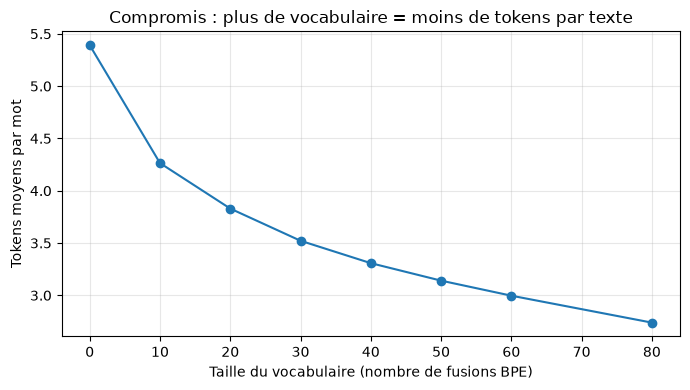

In [6]:
# Graphique du compromis (output PNG committé, C.2).
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

ms = [c[0] for c in curve]
vs = [c[1] for c in curve]
plt.figure(figsize=(7, 4))
plt.plot(ms, vs, 'o-', color='tab:blue')
plt.xlabel('Taille du vocabulaire (nombre de fusions BPE)')
plt.ylabel('Tokens moyens par mot')
plt.title('Compromis : plus de vocabulaire = moins de tokens par texte')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Lecture du résultat — le compromis

La courbe est **concave** : le gain en compression est fort au début (caractères → ~30 fusions), puis s'essouffle. Ajouter des fusions coûte des symboles en vocabulaire pour un gain de plus en plus marginal. Ce n'est pas « plus c'est gros, mieux c'est » : c'est une **décision d'ingénierie** qui dépend de ce qu'on veut payer — de la mémoire de vocabulaire ou de la longueur de séquence.

## 7. Comparer au tokenizer réel de la stack

Le corpus ci-dessus est notre jouet. La stack utilise un **tokenizer BPE de modèle** : le tokenizer d'un Qwen auto-hébergé (`Qwen/Qwen3.5-0.8B`) — la même famille BPE que le modèle de service des sections GenAI. On encode *les mêmes phrases* avec les trois tokenizers (mots, notre BPE, le Qwen réel) et on compte les tokens.

In [7]:
# Le tokenizer réel de la stack (même famille BPE que le service, disponible en local).
from transformers import AutoTokenizer

# Qwen3.5-0.8B : tokenizer BPE auto-hébergé. (téléchargé une fois, mis en cache)
qwen = AutoTokenizer.from_pretrained('Qwen/Qwen3.5-0.8B')
print(f"Tokenizers chargé : {type(qwen).__name__}, vocabulaire de {qwen.vocab_size} tokens.")

phrases = [
    'Le corbeau tient un fromage.',
    'La fourmi n est pas prêteuse.',
    'La patience vaut mieux que la force.',
]

# Comparaison équitable : on tokenise les MÊMES mots (ponctuation retirée) pour les trois.
def norm_words(p):
    return re.findall(r"[a-zà-ÿ'éèêëïôöûüç0-9-]+", p.lower())

tot_mots = sum(len(norm_words(p)) for p in phrases)
tot_bpe  = sum(len(BPE_encode(w)) for p in phrases for w in norm_words(p))
tot_qwen = sum(len(qwen.encode(' '.join(norm_words(p)))) for p in phrases)

print(f"{'tokenizer':<22}{'vocab':>8} | tokens sur {len(phrases)} phrases (texte normalisé)")
print(f"{'mots':<22}{len(vocab_mots):>8} | {tot_mots}")
print(f"{'notre BPE (60)':<22}{len(MERGES)+len(vocab_chars):>8} | {tot_bpe}")
print(f"{'Qwen (réel)':<22}{qwen.vocab_size:>8} | {tot_qwen}")

Tokenizers chargé : Qwen2Tokenizer, vocabulaire de 248044 tokens.
tokenizer                vocab | tokens sur 3 phrases (texte normalisé)
mots                       188 | 18
notre BPE (60)              93 | 46
Qwen (réel)             248044 | 21


### Lecture du résultat — l'écart entre notre jouet et le réel

Sur ces trois phrases, le découpage par mots donne 18 tokens, le Qwen réel (248 044) **21**, et notre BPE jouet (93) **46** — plus de deux fois plus. Le Qwen garde presque chaque mot français entier, alors que notre petit vocabulaire les éclate en sous-mots. **La taille du vocabulaire n'est pas décorative** : elle détermine à quel point un texte courant est compact. L'écart du Qwen se creuserait encore sur les mots rares / noms propres / langues peu représentées — là où il garde des fragments que notre jouet, qui ne les a jamais vus, doit décomposer en caractères.

## 8. Le coût du choix — chunking RAG et budget de contexte

Le tokenizer n'est pas un détail : il détermine **combien de tokens tient un chunk RAG** et **combien de chunks couvre un budget de contexte** fixe. On prend un document (le corpus), on le tokenise avec deux BPE de tailles différentes, et on mesure combien de chunks de `MAX_TOKENS` il faut pour le couvrir.

In [8]:
# Impact du choix de tokenizer sur le nombre de chunks à budget fixe.
MAX_TOKENS = 128   # budget de contexte par chunk RAG

def n_chunks(tokens, max_tokens):
    return -(-len(tokens) // max_tokens)   # division entière par excès

doc_tokens_words  = WORDS  # un token = un mot (naïf)
doc_tokens_bpe_s  = [t for w in WORDS for t in make_bpe(train_bpe(WORDS, 20))[0](w)]
doc_tokens_bpe_l  = [t for w in WORDS for t in make_bpe(train_bpe(WORDS, 80))[0](w)]
doc_tokens_qwen   = qwen.encode(' '.join(WORDS))

print(f"{'Choix de tokenizer':<22}{'# tokens':>9}{'chunks@'+str(MAX_TOKENS):>12}")
for name, toks in [('mots', doc_tokens_words),
                   ('BPE 20', doc_tokens_bpe_s),
                   ('BPE 80', doc_tokens_bpe_l),
                   ('Qwen (réel)', doc_tokens_qwen)]:
    print(f"{name:<22}{len(toks):>9}{n_chunks(toks, MAX_TOKENS):>12}")

Choix de tokenizer     # tokens  chunks@128
mots                        299           3
BPE 20                     1145           9
BPE 80                      819           7
Qwen (réel)                 419           4


### Lecture du résultat — la décision d'ingénierie, pas la mécanique

Les chiffres disent la vraie leçon. Le découpage **par mots** est ici le plus compact (299 tokens, 3 chunks), mais c'est un tokenizer « paresseux » : vocabulaire ouvert, il échoue sur tout mot jamais vu. Notre BPE **jouet** (petit vocabulaire) éclate les mots français en sous-mots → 1145 (BPE 20) et 819 (BPE 80) tokens, donc **plus de chunks** (9 et 7). Le **Qwen réel** (gros vocabulaire) est presque au niveau du mot : 419 tokens, 4 chunks.

À budget de contexte fixe (`MAX_TOKENS`), **plus le vocabulaire est gros, plus le texte est compact, moins il faut de chunks — mais plus le tokenizer coûte à stocker.** Le tokenizer est une variable de coût (mémoire de vocabulaire vs longueur de séquence vs nombre de chunks), pas un détail d'implémentation.

## 9. Cas pathologiques — nombres, accents, OOV, et le piège du comptage de lettres

Certains mots posent des cas que le tokenizer doit gérer : les **nombres**, les **accents**, les **mots rares/inconnus** (hors-vocabulaire), et le piège classique du **comptage de lettres** que les LLM « ratent ».

In [9]:
# Cas pathologiques : nombres, accents, inconnus, et le comptage de lettres.
exemples = ['strawberry', 'élève', '1234', 'coeur', 'hors-normes', 'aérodrome 42']

print("Mot / expression      | tokens BPE | nombre de lettres (ce que l'œil compte)")
for s in exemples:
    toks = qwen.encode(s)
    print(f"{s!r:>22} | {toks!r:<18} | {len(s.replace(' ', ''))}")
print()
print('Pour « strawberry » : le modèle le voit en', len(qwen.encode('strawberry')), 'tokens (', qwen.decode(qwen.encode('strawberry')), ')')
print("→ compter les lettres « à l'œil » (10) ne se retrouve PAS dans la découpe, car le mot est fragmenté.")

Mot / expression      | tokens BPE | nombre de lettres (ce que l'œil compte)
          'strawberry' | [485, 654, 14911]  | 10
               'élève' | [236940]           | 5
                '1234' | [16, 17, 18, 19]   | 4
               'coeur' | [981, 12199]       | 5
         'hors-normes' | [206516, 5111, 483, 287] | 11
        'aérodrome 42' | [64, 933, 22771, 6439, 220, 19, 17] | 11

Pour « strawberry » : le modèle le voit en 3 tokens ( strawberry )
→ compter les lettres « à l'œil » (10) ne se retrouve PAS dans la découpe, car le mot est fragmenté.


### Lecture du résultat — la cause du « comptage faux »

Les nombres (`1234` → 4 tokens) sont éclatés en chiffres, les accents (`élève`, `aérodrome`) tiennent souvent en un token, et un mot inconnu retombe sur des **fragments** plus petits. Le fameux « strawberry » : le modèle le découpe en sous-mots (`straw` + `berry`), donc « compter les r » à partir de sa représentation interne est une **question mal posée** — les lettres ne sont pas des unités de sa représentation. Ce n'est pas une erreur du modèle, c'est la conséquence directe de la tokenisation.

**Cas hors-vocabulaire.** Un tokenizer ne voit jamais de `OOV` avec `</w>` : il retombe sur les **fragments** appris. Notre BPE *jouet* retombe sur des caractères ; le Qwen réel, sur des fragments de son gros vocabulaire. C'est la différence entre un vocabulaire de 78 caractères et un de 248 044.

## 10. Exercices

Les exercices suivants laissent la main à l'étudiant : implémenter, comparer, ou rapprocher d'un cas réel.

In [10]:
# Exercice 1 — Entraîne un BPE sur un autre corpus français (par exemple le vôtre),
# et compare l'ordre des premières fusions. Pourquoi « le » apparaît-il tôt ?
# → écrire ici votre implémentation ou votre réponse.
print("Exercice 1 a completer")

Exercice 1 a completer


In [11]:
# Exercice 2 — Le tokenizer Qwen encode « 3.14 » et « 3,14 » : combien de tokens chacun ?
# Testez, puis expliquez la différence de découpe. Laquelle représente le mieux le nombre ?
# → écrire ici votre réponse.
result = None  # TODO etudiant
print("Exercice 2 a completer")

Exercice 2 a completer


In [12]:
# Exercice 3 — Prenez un document de 1000 mots. Estimez (et vérifiez) combien de chunks de
# 256 tokens il occupe avec notre BPE à 60 fusions, puis avec le Qwen réel. Lequel « coûte
# le moins » et pourquoi ? → écrire ici votre estimation puis votre mesure.
print("Exercice 3 a completer")

Exercice 3 a completer


## Continuer le parcours

La tokenisation détermine le nombre de tokens par chunk ; l'étape suivante consiste à stocker et retrouver les vecteurs produits à partir de ces chunks :

- [`05-Stockage-Vectoriel.ipynb`](05-Stockage-Vectoriel.ipynb) — stockage local, suite aval directe ;
- [`02-Retrieval-Avance.ipynb`](02-Retrieval-Avance.ipynb) — retour au retrieval pour mesurer comment chunking et classement interagissent.

Cette cellule de navigation conclut le notebook sans modifier les exercices ni leurs outputs.